In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from feature_engine.outliers import Winsorizer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset = pd.read_csv("Airline_Passenger_Satisfaction.csv")
dataset.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,neutral or dissatisfied,Loyal Customer,39,Business travel,Business,4983,5,4,4,3,...,5,5,4,5,5,3,4,5,0,9
1,satisfied,Loyal Customer,60,Business travel,Business,4983,4,4,5,2,...,5,4,4,5,4,5,4,5,0,13
2,satisfied,Loyal Customer,37,Business travel,Business,2200,5,3,3,3,...,5,4,4,5,5,4,4,5,4,29
3,neutral or dissatisfied,Disloyal Customer,40,Business travel,Business,1004,5,3,4,3,...,3,4,2,5,2,3,4,3,14,23
4,neutral or dissatisfied,Loyal Customer,39,Business travel,Eco,1663,2,3,4,2,...,4,4,1,2,3,3,3,3,58,74


In [3]:
x = dataset.drop(["satisfaction"], axis=1)
y = dataset["satisfaction"]

In [4]:
x.head()

,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,Loyal Customer,39,Business travel,Business,4983,5,4,4,3,3,...,5,5,4,5,5,3,4,5,0,9
1,Loyal Customer,60,Business travel,Business,4983,4,4,5,2,2,...,5,4,4,5,4,5,4,5,0,13
2,Loyal Customer,37,Business travel,Business,2200,5,3,3,3,4,...,5,4,4,5,5,4,4,5,4,29
3,Disloyal Customer,40,Business travel,Business,1004,5,3,4,3,2,...,3,4,2,5,2,3,4,3,14,23
4,Loyal Customer,39,Business travel,Eco,1663,2,3,4,2,2,...,4,4,1,2,3,3,3,3,58,74


In [5]:
y.head()

0    neutral or dissatisfied
1                  satisfied
2                  satisfied
3    neutral or dissatisfied
4    neutral or dissatisfied
Name: satisfaction, dtype: object

In [6]:
numeric_feature = x.select_dtypes(exclude=["object"]).columns
catag_feature = x.select_dtypes(include=["object"]).columns

In [7]:
numeric_feature

Index(['Age', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='object')

In [8]:
catag_feature

Index(['Customer Type', 'Type of Travel', 'Class'], dtype='object')

In [9]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("winsorizer", Winsorizer(capping_method="iqr", tail="both", fold=1.5)),
    ("scaler", MinMaxScaler())
])

In [10]:
catag_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

In [11]:
preprocess_pipeline = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_feature),
    ("catag", catag_pipeline, catag_feature)
])

In [12]:
clean = preprocess_pipeline.fit(x)

In [13]:
Clean_data = pd.DataFrame(clean.transform(x))

In [14]:
Clean_data.head()

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,0.470588,1.000000,1.000000,0.714286,0.8,0.428571,0.6,0.428571,1.000000,1.000000,...,1.000000,0.428571,0.714286,1.000000,0.000000,0.189474,1.0,0.0,0.0,0.0
1,0.779412,1.000000,0.714286,0.714286,1.0,0.142857,0.4,0.714286,1.000000,0.714286,...,0.714286,1.000000,0.714286,1.000000,0.000000,0.273684,1.0,0.0,0.0,0.0
2,0.441176,0.440869,1.000000,0.428571,0.6,0.428571,0.8,0.714286,1.000000,0.714286,...,1.000000,0.714286,0.714286,1.000000,0.123077,0.610526,1.0,0.0,0.0,0.0
3,0.485294,0.190974,1.000000,0.428571,0.8,0.428571,0.4,0.142857,0.428571,0.714286,...,0.142857,0.428571,0.714286,0.428571,0.430769,0.484211,0.0,0.0,0.0,0.0
4,0.470588,0.328667,0.142857,0.428571,0.8,0.142857,0.4,0.142857,0.714286,0.714286,...,0.428571,0.428571,0.428571,0.428571,1.000000,1.000000,1.0,0.0,1.0,0.0


In [15]:
joblib.dump(clean, "decision_tree_preprocess_pipeline.pkl")

['decision_tree_preprocess_pipeline.pkl']

In [16]:
joblib.load("decision_tree_preprocess_pipeline.pkl")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('catag', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

In [17]:
x_train, x_test, y_train, y_test = train_test_split(
    Clean_data, y, test_size=0.2, random_state=42
)

In [18]:
model = DecisionTreeClassifier(
    random_state=42
)

In [19]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6, 7, 8],
    "min_samples_split": [10, 20, 30, 50],
    "min_samples_leaf": [5, 10, 15, 20, 30],
    "max_features": ["sqrt", "log2"],
    "ccp_alpha": [0.001, 0.005, 0.01, 0.02]
}

In [20]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=1,
    verbose=1
)


In [21]:
grid.fit(x_train, y_train)

Fitting 5 folds for each of 2240 candidates, totalling 11200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0.001, 0.005, ...], 'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'max_features': ['sqrt', 'log2'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fol

In [23]:
y_train_pred = grid.predict(x_train)
y_test_pred = grid.predict(x_test)

In [24]:
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))

Training Accuracy: 0.7140052356020943
Testing Accuracy: 0.717623960578996


In [25]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


Confusion Matrix:
[[ 4382  5417]
 [ 1918 14259]]


In [26]:
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Classification Report:
                         precision    recall  f1-score   support

neutral or dissatisfied       0.70      0.45      0.54      9799
              satisfied       0.72      0.88      0.80     16177

               accuracy                           0.72     25976
              macro avg       0.71      0.66      0.67     25976
           weighted avg       0.71      0.72      0.70     25976



In [27]:
joblib.dump(model, "decision_tree.pkl")

['decision_tree.pkl']

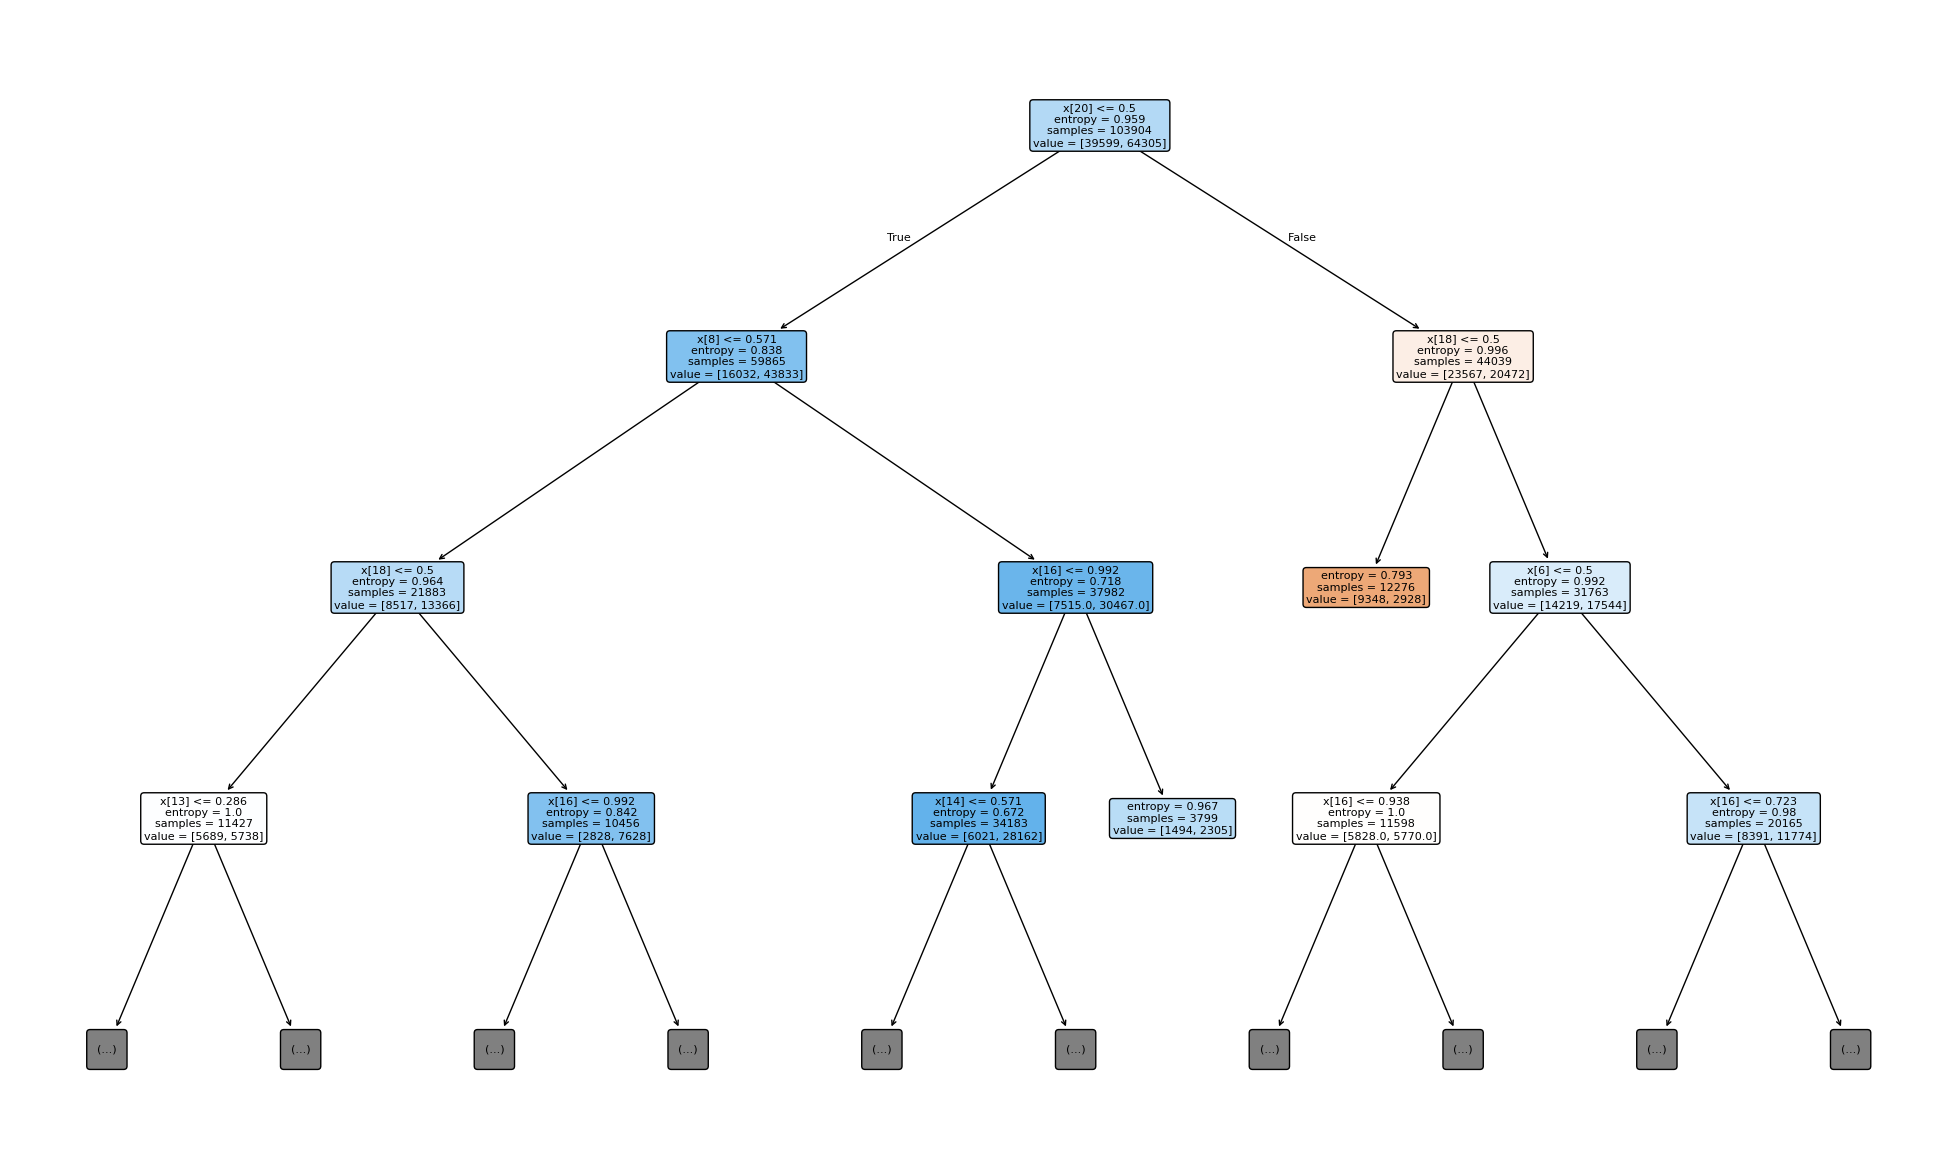

In [30]:
best_dt = grid.best_estimator_

plt.figure(figsize=(25, 15))

tree.plot_tree(
    best_dt,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.show()